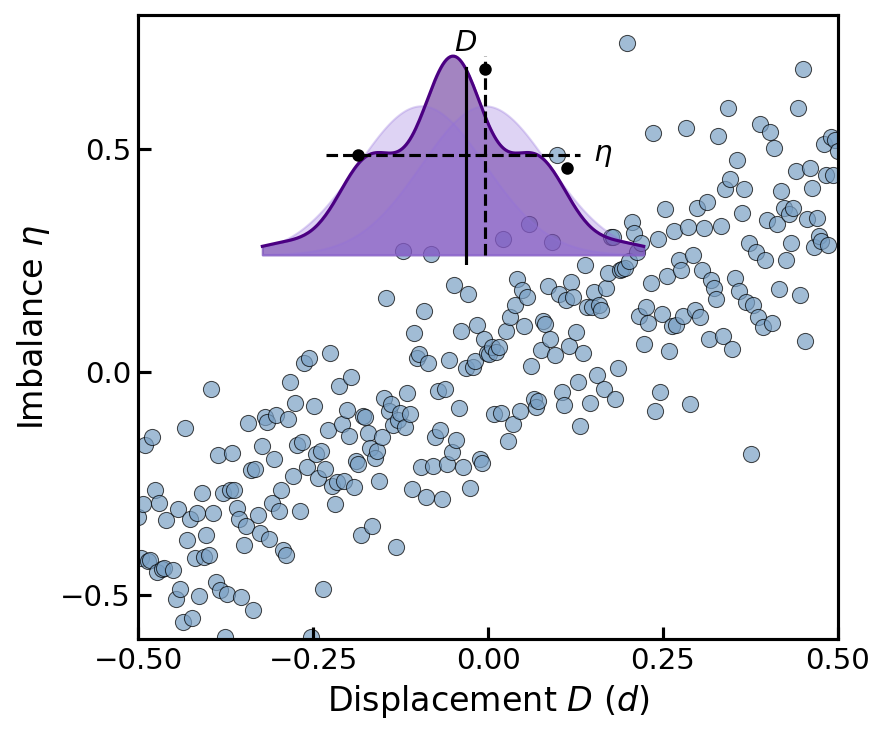

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# --- Data Simulation ---
np.random.seed(42)

# Main Scatter: Imbalance (eta) vs Displacement (D)
# Linear trend + noise
D_scatter = np.linspace(-0.5, 0.5, 300)
# Create spread that widens slightly at extremes
spread = 0.15
eta_scatter = 0.8 * D_scatter + np.random.normal(0, spread, 300)

# Inset Distribution Data
# Overlapping Gaussian-like peaks to mimic interference pattern
x_dist = np.linspace(-3, 3, 200)
def gaussian(x, mu, sigma):
    return np.exp(-((x - mu)**2) / (2 * sigma**2))

# Multi-peak distribution (purple shaded area)
dist_envelope = gaussian(x_dist, 0, 1.2)
dist_ripple = 0.2 * np.cos(4 * x_dist) * dist_envelope
dist_total = dist_envelope + dist_ripple
# Normalize to reasonable height
dist_total = 0.8 * (dist_total / np.max(dist_total))

# Shifted ghosts (lighter purple)
dist_left = 0.6 * gaussian(x_dist, -0.5, 1.0)
dist_right = 0.6 * gaussian(x_dist, 0.5, 1.0)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# 1. Main Scatter Plot
ax.scatter(D_scatter, eta_scatter, 
           alpha=0.7, 
           s=60, 
           edgecolors='black', 
           linewidth=0.5,
           color='#7aa0c4', 
           label='Data')

# Styling Main Axes
ax.set_xlabel(r'Displacement $D$ ($d$)', fontsize=16)
ax.set_ylabel(r'Imbalance $\eta$', fontsize=16)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.6, 0.8)
ax.tick_params(direction='in', length=6, width=1.5, labelsize=14)
ax.set_xticks([-0.50, -0.25, 0.00, 0.25, 0.50])
ax.set_yticks([-0.5, 0.0, 0.5])
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# 2. Inset: Distribution Overlay
# Position: [left, bottom, width, height] in figure fraction
ax_ins = ax.inset_axes([0.15, 0.6, 0.6, 0.35], transform=ax.transAxes)

# Draw filled distributions
ax_ins.fill_between(x_dist, dist_total, color='rebeccapurple', alpha=0.6)
ax_ins.plot(x_dist, dist_total, color='indigo', linewidth=1.5)

# Draw ghost distributions behind
ax_ins.fill_between(x_dist, dist_left, color='mediumpurple', alpha=0.3)
ax_ins.fill_between(x_dist, dist_right, color='mediumpurple', alpha=0.3)

# Annotations on Inset
# Vertical line at D (center)
ax_ins.axvline(0.2, ymax=0.9, color='black', linestyle='-', linewidth=1.5) # Solid D line
ax_ins.text(0.2, 0.95, '$D$', ha='center', va='bottom', fontsize=14, transform=ax_ins.get_xaxis_transform())

# Dashed crosshair
ax_ins.hlines(0.4, -2, 2, colors='black', linestyles='--', linewidth=1.5)
ax_ins.vlines(0.5, 0, 0.8, colors='black', linestyles='--', linewidth=1.5)

# Points
ax_ins.plot([-1.5, 0.5, 1.8], [0.4, 0.75, 0.35], 'ko', markersize=5) # Black dots

# Label eta
ax_ins.text(2.2, 0.4, r'$\eta$', va='center', fontsize=14)

# Hide inset axes
ax_ins.axis('off')

plt.tight_layout()
plt.show()
